In [3]:
import serial
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft, ifft, fftfreq
from scipy.signal import windows

In [4]:
voltajes1 = []
voltajes2 = []
voltajes3 = []
voltajes4 = []

In [50]:
puerto = 'COM10'
baudrate = 115200

ser = serial.Serial(puerto, baudrate, timeout=1)

print('conectando al puerto', puerto)

ser.reset_input_buffer()
ser.write(b'a')

print("comando 'a' enviado")

voltajes = []
tiempo = []

print('recibiendo datos...\n')

N = 60000
count = 0

while count < N:
    linea = ser.readline().decode('utf-8', errors='ignore').strip()
    count += 1
    tiempo.append(count)

    if not linea:
        voltajes.append(np.nan)   # ← dato faltante
        print('dato perdido')
        continue

    try:
        v = float(linea)
        voltajes.append(v)
        print(f'voltaje: {v} mV')

    except ValueError:
        voltajes.append(np.nan)

ser.close()
print('transmisión finalizada')

# -----------------------------
# INTERPOLACIÓN DE HUECOS
# -----------------------------

voltajes = np.array(voltajes, dtype=float)
tiempo = np.array(tiempo)

mask = ~np.isnan(voltajes)

voltajes_interp = np.interp(tiempo, tiempo[mask], voltajes[mask])
#voltajes1.append(voltajes_interp)
# -----------------------------
# GRAFICAR
# -----------------------------

plt.plot(tiempo, voltajes_interp, label='Interpolado')
plt.scatter(tiempo, voltajes, s=5, alpha=0.3, label='Datos crudos')
plt.title('Medición ADC')
plt.xlabel('Tiempo (ms)')
plt.ylabel('Voltaje')
plt.grid(True)
plt.legend()
plt.show()


conectando al puerto COM10
comando 'a' enviado
recibiendo datos...

voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
voltaje: 0.0 mV
volt

KeyboardInterrupt: 

Frecuencia dominante: 0.850 Hz


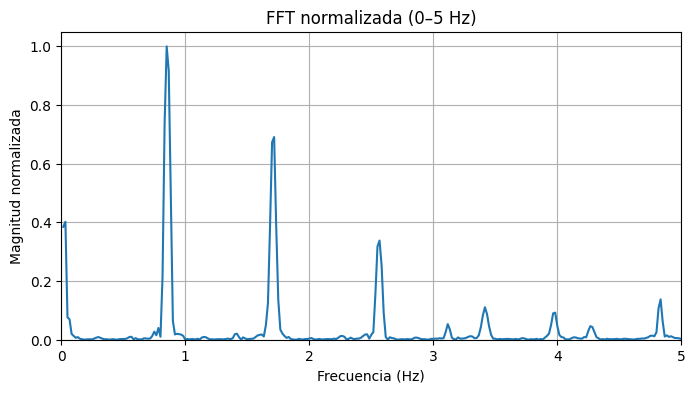

In [49]:

# parámetros
fs = 1000  # Hz
N = len(voltajes)

# limpiar señal
voltajes = np.nan_to_num(voltajes, nan=0.0, posinf=0.0, neginf=0.0)

# quitar DC
signal = voltajes - np.mean(voltajes)

# ventana (reduce fuga espectral)
window = windows.hann(N)
signal_w = signal * window

# FFT
Y = fft(signal_w)
freqs = fftfreq(N, 1/fs)

# solo frecuencias positivas
mask = freqs > 0
freqs_pos = freqs[mask]
Y_pos = np.abs(Y[mask])

# normalización (0 a 1)
Y_norm = Y_pos / np.max(Y_pos)

# frecuencia dominante (ignorar DC)
fmin = 0.2
valid = freqs_pos >= fmin
idx = np.argmax(Y_norm[valid])
f0 = freqs_pos[valid][idx]

print(f"Frecuencia dominante: {f0:.3f} Hz")


# gráfico
plt.figure(figsize=(8,4))
plt.plot(freqs_pos, Y_norm)
plt.xlim(0, 5)          # 🔍 zoom 0–5 Hz
plt.ylim(0, 1.05)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud normalizada")
plt.title("FFT normalizada (0–5 Hz)")
plt.grid(True)
plt.show()

In [44]:
voltajes4.append(voltajes_interp)

In [66]:
voltajes3

[array([0., 0., 0., ..., 0., 0., 0.], shape=(60000,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(60000,))]

In [45]:
frecuencias1.append(f0)

In [72]:
import numpy as np
import os


# --- Apilar como columnas ---
M = np.column_stack(voltajes4)

# --- Ruta (directorio actual) ---
ruta = os.path.join(os.getcwd(), "voltajes4.csv")

# --- Guardar CSV ---
np.savetxt(
    ruta,
    M,
    delimiter=",",
    header="124.32g",
    comments="",
    fmt="%.6f"
)
#,124.32g,171.73g,221.2g

print("Archivo guardado en:")
print(ruta)


Archivo guardado en:
c:\Users\estudiante.fcen\Desktop\voltajes4.csv


C:\Users\estudiante.fcen\AppData\Local\Temp\ipykernel_9236\3549293723.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


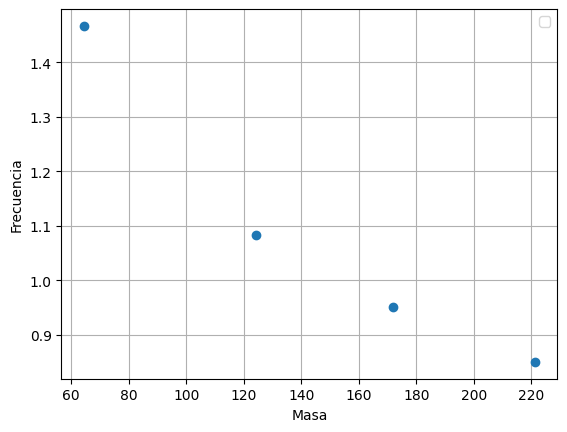

In [55]:
m = [64.47 , 124.32 , 171.73 , 221.2]
plt.plot(m,frecuencias1,"o")
plt.xlabel("Masa")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid()
plt.show()